# Regression Metrices


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving placement.csv to placement.csv


In [3]:
df = pd.read_csv('placement.csv')

In [4]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package(in lpa)')

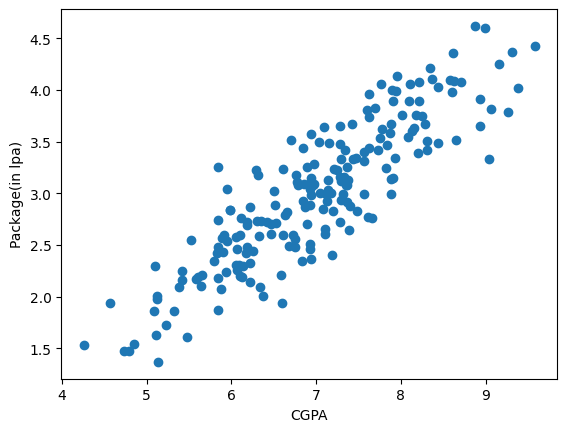

In [5]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [6]:
x = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [7]:
y

,package
0,3.26
1,1.98
2,3.25
3,3.67
4,3.57
...,...
195,2.46
196,2.57
197,3.24
198,3.96


In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
lr = LinearRegression()

In [11]:
lr.fit(X_train,y_train)

LinearRegression()

In [12]:
X_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [13]:
y_test

,package
112,4.10
29,3.49
182,2.08
199,2.33
193,1.94
85,1.48
10,1.86
54,3.09
115,4.21
35,2.87


In [14]:
lr.predict(X_test.iloc[2].values.reshape(1,1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.38464568])

Text(0, 0.5, 'Package(in lpa)')

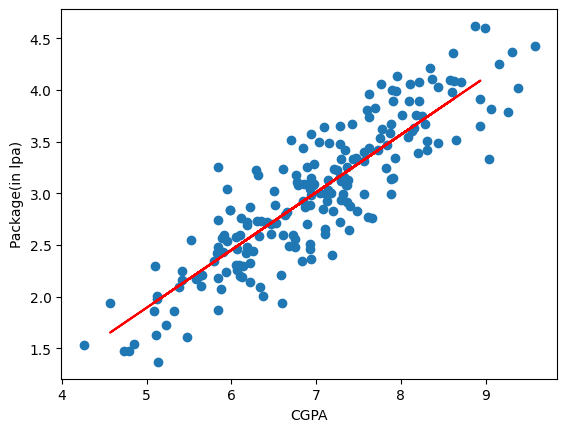

In [15]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_test,lr.predict(X_test),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [21]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [27]:
y_pred = lr.predict(X_test)

In [28]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [32]:
print("MAE =",mean_absolute_error(y_test,y_pred))

MAE = 0.2884710931878175


In [35]:
print("MSE =",mean_squared_error(y_test,y_pred))

MSE = 0.12129235313495527


In [38]:
print("RMSE =",np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE = 0.34827051717731616


In [42]:
print("R2 Score =",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 Score = 0.780730147510384


In [51]:
# Adjusted R2 Score
X_test.shape

(40, 1)

In [53]:
# Adj_R2 = 1 - ((1-r2)*(n-1))/(n-1-k)

Adj_R2 = 1 - ((1-r2)*(40-1))/(40-1-1)
print("Adjusted R2 Score =",Adj_R2)

Adjusted R2 Score = 0.7749598882343415


In [71]:
# Adding Columns to Check Variation in R2 and Adj_R2 Score.

new_df = df.copy()
new_df['random_feature'] = np.random.random(200)

new_df = new_df[['cgpa','random_feature','package']]
new_df.head()

,cgpa,random_feature,package
0,6.89,0.874603,3.26
1,5.12,0.032648,1.98
2,7.82,0.860640,3.25
3,7.42,0.316243,3.67
4,6.94,0.818670,3.57


Text(0, 0.5, 'Package(in lpa)')

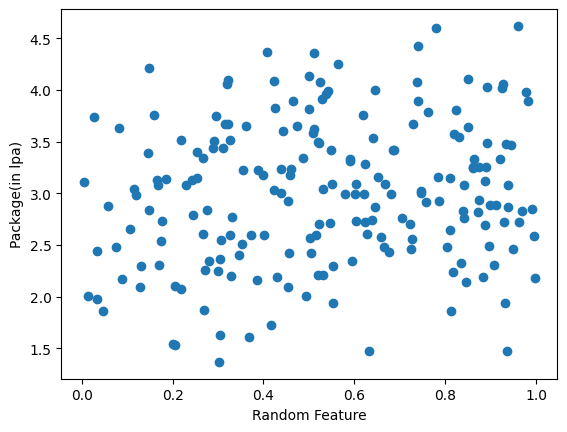

In [72]:
plt.scatter(new_df['random_feature'],new_df['package'])
plt.xlabel('Random Feature')
plt.ylabel('Package(in lpa)')

In [81]:
x = new_df.iloc[:,0:2]
y = new_df.iloc[:,-1]

In [82]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [83]:
lr = LinearRegression()

In [84]:
lr.fit(X_train,y_train)

LinearRegression()

In [85]:
y_pred = lr.predict(X_test)

In [86]:
print("R2 Score =",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 Score = 0.7796768838800912


In [87]:
# Adj_R2 = 1 - ((1-r2)*(n-1))/(n-1-k)

Adj_R2 = 1 - ((1-r2)*(40-1))/(40-1-2)
print("Adjusted R2 Score =",Adj_R2)

# --> The Adjusted R2 Score is decreased.

Adjusted R2 Score = 0.767767526251988
